# Multi-variable Linear Regression - Building Everything From Scratch

## Imports

In [2]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

In [ ]:
import models
import toolkit

importlib.reload(models)
importlib.reload(toolkit)

from models import *
from toolkit import *

## Data Loading, Cleaning and Preparation

In [4]:
df = pd.read_csv("./datasets/Salary_Data.csv")

print("Original dataset size: ", len(df))

Original dataset size:  6704


### Dropping rows containing NAN value

In [5]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [6]:
dropped_rows = df[df.isnull().any(axis=1)]
df = df.dropna()

print("Number of dropped rows: ", len(dropped_rows))

Number of dropped rows:  6


### Job Title Encoding

Job titles were target-encoded (mean-encoded) using the target variable `Salary`.

To prevent the **Rare Label Trap** (where categories with low occurrence heavily overfit to anomalous target values), job titles with a frequency of **`<= 10`** were bucketed into a single `"Other"` category before calculating the mean salary.

*(Note: Target Encoding natively transforms the label into a continuous floating point float.)*

In [35]:
# Clean the job title strings
job_titles_clean = df.loc[df.index, "Job Title"].astype("string").str.strip()

# Calculate frequencies of each job title
job_title_counts = job_titles_clean.value_counts()

# Mask rare job titles (<= 10) into "Other"
rare_mask = job_titles_clean.isin(job_title_counts[job_title_counts <= 10].index)

job_titles_grouped = job_titles_clean.copy()
job_titles_grouped[rare_mask] = "Other"

# Target encode the grouped job titles using the mean Salary
# Note: Ideally, target encoding should be fit strictly on the training set individually to avoid Target Leakage.
# For simplicity in this unified preprocessing flow, it is applied globally across the entire dataset here.
target_means = df.groupby(job_titles_grouped)["Salary"].mean()

df["Job_Title_ID"] = job_titles_grouped.map(target_means)

job_title_mapping = pd.DataFrame({
    "Job Title (Grouped)": target_means.index,
    "Target Mean (Job_Title_ID)": target_means.values,
    "Frequency": job_titles_grouped.value_counts().reindex(target_means.index).values
}).sort_values("Target Mean (Job_Title_ID)", ascending=False).reset_index(drop=True)

print(f"Grouped into {len(target_means)} categories (including 'Other').")

display(df)

Grouped into 56 categories (including 'Other').


,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Job_Title_ID,Gender_ID,Education_Level_ID
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,113243.243243,0,1
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,125090.909091,1,2
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,92711.616162,0,3
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,35857.142857,1,1
4,52.0,Male,Master's,Director,20.0,200000.0,92711.616162,0,2
...,...,...,...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0,137840.909091,1,3
6700,32.0,Male,High School,Sales Associate,3.0,50000.0,35857.142857,0,0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0,143059.701493,1,1
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0,117164.705882,0,2


### Gender Encoding

`Male` was mapped to `0` and `Female` to `1`.

Rows with unsupported gender values were removed before encoding.

In [ ]:
gender_mapping = {
    "Male": 0,
    "Female": 1,
}

gender_clean = df["Gender"].astype("string").str.strip()
unsupported_gender_mask = ~gender_clean.isin(gender_mapping)

if unsupported_gender_mask.any():
    unsupported_gender_values = sorted(gender_clean[unsupported_gender_mask].dropna().unique())
    print(
        "Dropping",
        int(unsupported_gender_mask.sum()),
        "rows with unsupported Gender values:",
        unsupported_gender_values,
    )
    df = df.loc[~unsupported_gender_mask].copy()
    gender_clean = df["Gender"].astype("string").str.strip()

df["Gender_ID"] = gender_clean.map(gender_mapping).astype("Int64") # pyright: ignore[reportPossiblyUnboundVariable]

df[["Gender", "Gender_ID"]].drop_duplicates().sort_values("Gender_ID") # pyright: ignore[reportPossiblyUnboundVariable]

,Gender,Gender_ID
0,Male,0
1,Female,1


### Education Encoding

Education levels were grouped into four numeric categories.

Equivalent text variants such as `Bachelor's` and `Bachelor's Degree` share the same code.

In [10]:
education_mapping = {
    "High School": 0,
    "Bachelor's Degree": 1,
    "Bachelor's": 1,
    "Master's Degree": 2,
    "Master's": 2,
    "PhD": 3,
    "phD": 3,
}

education_clean = df["Education Level"].astype("string").str.strip()
df["Education_Level_ID"] = education_clean.map(education_mapping).astype("Int64")

if df["Education_Level_ID"].isna().any():
    unexpected_education_values = sorted(
        education_clean[df["Education_Level_ID"].isna()].dropna().unique()
    )
    raise ValueError(
        f"Unmapped Education Level values found: {unexpected_education_values}"
    )

df[["Education Level", "Education_Level_ID"]].drop_duplicates().sort_values(
    ["Education_Level_ID", "Education Level"]
)

,Education Level,Education_Level_ID
2395,High School,0
0,Bachelor's,1
944,Bachelor's Degree,1
1,Master's,2
945,Master's Degree,2
2,PhD,3
5878,phD,3


In [11]:
df_clean = df[["Age", "Gender_ID", "Education_Level_ID", "Job_Title_ID", "Years of Experience", "Salary"]]

### Report Summary (Data Changes)

- Original loaded dataset shape: **(6704, 6)**.
- Removed **6 rows** containing missing values, resulting in **(6698, 6)**.
- During binary gender encoding (`Male=0`, `Female=1`), removed **14 rows** with unsupported `Gender` value (`Other`).
- Added encoded feature columns: `Job_Title_ID`, `Gender_ID`, and `Education_Level_ID`.
- Final engineered dataset shape (`df`): **(6684, 9)**.
- Final modeling subset shape (`df_clean`): **(6684, 6)**.
- **Features**: `Age`, `Gender_ID`, `Education_Level_ID`, `Job_Title_ID`, `Years_of_Experience`
- **Label**: `Salary`

## Correlation Matrix of Features

In [12]:
age = df_clean["Age"].to_numpy(dtype=np.float64)
gender = df_clean["Gender_ID"].to_numpy(dtype=np.float64)
education = df_clean["Education_Level_ID"].to_numpy(dtype=np.float64)
job_title = df_clean["Job_Title_ID"].to_numpy(dtype=np.float64)
experience = df_clean["Years of Experience"].to_numpy(dtype=np.float64)

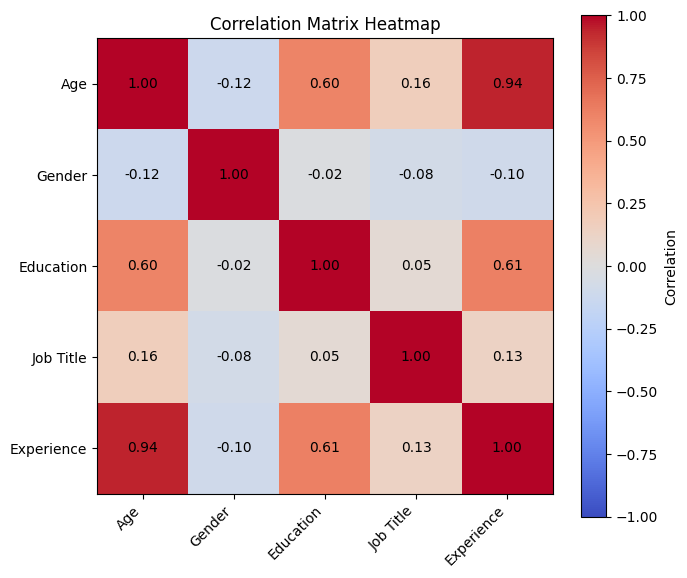

In [13]:
# 1) Build matrix
labels = ["Age", "Gender", "Education", "Job Title", "Experience"]
datasets = [age, gender, education, job_title, experience]

# 2) Plot heatmap
StatKit.plot_corr_matrix_heatmap(datasets, labels)


In [14]:
df_model = df_clean.drop(labels=["Age"], axis=1)

## Model Training, Prediction and Evaluation

In [15]:
model = MultiLinearRegression()

In [16]:
X = df_model.drop(labels=["Salary"], axis=1).to_numpy(dtype=np.float64)
y = df_model["Salary"].to_numpy(dtype=np.float64)

In [17]:
X_train, X_test, y_train, y_test = DatasetKit.split_dataset(X, y, 0.8)

In [18]:
features = list(X_train.T)

In [19]:
model.train(features, y_train)

In [20]:
y_pred = model.predict(list(X_test.T))

In [21]:
print("MAE", ModelMetrics.mean_absolute_error(y_pred, y_test))
print("R^2", ModelMetrics.r_squared(y_pred, y_test))

MAE 24787.19902958597
R^2 0.5573316990388526
